# Thermal Expansion Coefficient of LJ Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dlj_elasticity_analysis.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`

---

## Potential (for LJ glasses)

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, N=4000, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` ... `3dlj_N4000_s00009.dat` automatically
and writes **`elasticity_results.txt`**:

```
# serial   pressure    u_per_N      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   →  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, exactly what the theory predicts.

---


## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis:

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                                   # directory containing all output files
TEMPERATURES = 0.000001, 0.000005, 0.000010, 0.000015, 0.000020, 0.000025, 0.000030, 0.000035, 0.000040
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Load bulk modulus K from `elasticity_results.txt`

In [40]:
elas = np.loadtxt(Path(DATA_DIR) / '3dlj_elasticity_N4000_s000.dat', comments='#')

# columns: serial  u_per_N  pressure  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
u_per_N = elas[:, 1]   # potential energy per atom
P0      = elas[:, 2]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

# build per-glass K dict for lookup later
K_per_glass = {serials[i]: K[i] for i in range(len(serials))}

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Changes made in previous NVT_NH.c for LJ glasses

1. N changed from 16000 to 4000 as its hard coded in LJ glass files
2. Calculated RHO; from your glass files checked L = 19.4814... from the first line, so V = L³ = 7393.7, and ρ = N/V = 4000/7393.7 = 0.541.
3. CUTOFF_SQRD (1.48²) → added explicit CUTOFF 2.5 and CUTOFF_SQRD (CUTOFF*CUTOFF) : (was given in elasticity_analysis.c)
4. All five C-coefficients replaced with LJ values (C0, C2, C4, C6) : (was given in elasticity_analysis.c)
5. N_0 10.0 (IPL exponent) removed; replaced by N_REP 12.0 and N_ATT 6.0 as LJ glasses have 2 terms, attraction and replsion
6. At the low temperatures, in this case (T = 0.001 to 0.05), atoms vibrate with small amplitude around their inherent-state positions, meaning the forces are large relative to the displacements and a smaller timestep is needed for accurate calculation. (not sure about the orderr of difference it makes)

7. calculateForces():

Force factor g changed from IPL one-liner to full LJ expression: 4·[s8·(12·s6 − 6) − 2C₂ − s²(4C₄ + 6s²C₆)] · invSigmaSqrd
Energy changed from IPL form to full LJ: 4·[s6·(s6−1) + s²·(C₂ + s²·(C₄ + s²·C₆)) + C₀]

## Load NVT files — per-glass and population-averaged

For each glass we store its own time-series so we can do:
- **Per-glass** linear fit P_g(T) → dPdT_g  (correct comparison with alpha_theory_g)
- **Population mean** P̄(T) → mean dPdT  (headline number)

The error used for weighting is the **time-series standard error** of each glass's own
production run — NOT the inter-glass scatter, which is real physical variation and should
not suppress fit weights.


In [41]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()          # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))    # time-series SEM (NOT inter-glass)
    return T_meas, P_mean, P_err


#  per-glass storage: pg_data[g] = list of (T_meas, P_mean, P_err) 
pg_data = {g: [] for g in GLASSES}

#  population-level storage (averaged over glasses at each T) 
T_measured_list = []
P_mean_list     = []
P_err_list      = []   # mean of per-glass SEM 

print(f"{'T_target':>10}  {'T_measured':>12}  {'mean P_vir':>12}  {'mean_SEM':>10}  {'n_glasses':>10}")
print("-" * 62)

for T in TEMPERATURES:
    T_vals = []; P_vals = []; E_vals = []; missing = []
    for g in GLASSES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals.append(Tm); P_vals.append(Pm); E_vals.append(Pe)
            pg_data[g].append((Tm, Pm, Pe))
        else:
            missing.append(g)

    if missing:
        print(f"  T={T}: missing glasses {missing}")

    if P_vals:
        T_avg  = np.mean(T_vals)
        P_avg  = np.mean(P_vals)
        # error on the mean of means: combine individual SEMs in quadrature then /n
        P_sem  = np.sqrt(np.sum(np.array(E_vals)**2)) / len(E_vals)
        T_measured_list.append(T_avg)
        P_mean_list.append(P_avg)
        P_err_list.append(P_sem)
        print(f"{T:>12.6f}  {T_avg:>12.6f}  {P_avg:>12.6f}  {P_sem:>10.2e}  {len(P_vals):>10}")

T_arr = np.array(T_measured_list)
P_arr = np.array(P_mean_list)
E_arr = np.array(P_err_list)


  T_target    T_measured    mean P_vir    mean_SEM   n_glasses
--------------------------------------------------------------
    0.000001      0.000001     -0.015887    2.07e-07          10
    0.000005      0.000005     -0.015872    4.47e-07          10
    0.000010      0.000010     -0.015853    6.34e-07          10
    0.000015      0.000015     -0.016951    5.29e-06          10
    0.000020      0.000020     -0.015812    8.83e-07          10
    0.000025      0.000025     -0.017794    3.58e-05          10
    0.000030      0.000030     -0.018297    1.59e-05          10
    0.000035      0.000035     -0.016673    9.39e-06          10
    0.000040      0.000040     -0.016964    4.04e-05          10


## Fit P vs T — per-glass and population-averaged

Each glass gets its own weighted linear fit using **its own time-series errors**.
The population fit uses the combined SEM computed above.


In [42]:
def weighted_linear_fit(T_vals, P_vals, P_errs):
    """Weighted least-squares P = a + b*T.  Returns (intercept, slope, err_intercept, err_slope)."""
    w = 1.0 / np.array(P_errs)**2
    A = np.column_stack([np.ones_like(T_vals), T_vals])
    M = A.T @ np.diag(w) @ A
    coeffs = np.linalg.solve(M, A.T @ (w * np.array(P_vals)))
    errs   = np.sqrt(np.diag(np.linalg.inv(M)))
    return coeffs[0], coeffs[1], errs[0], errs[1]


#  per-glass fits 
pg_fit = {}   # g -> (P0_fit, dPdT, P0_err, dPdT_err)

print(f"{'Glass':>6}  {'P0_elasticity':>14}  {'P0_fit':>12}  {'disc%':>7}  {'dPdT':>10}  {'dPdT_err':>10}")
print("-" * 70)
for g in GLASSES:
    pts = pg_data[g]
    if len(pts) < 3:
        print(f"  g={g}: only {len(pts)} temperature points — skipping")
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    a, b, ea, eb = weighted_linear_fit(Tv, Pv, Ev)
    pg_fit[g] = (a, b, ea, eb)
    disc = (a - P0[g]) / abs(P0[g]) * 100 if P0[g] != 0 else float('nan')
    print(f"  {g:>4}  {P0[g]:>14.6f}  {a:>12.6f}  {disc:>+7.2f}%  {b:>10.5f}  {eb:>10.5f}")


# population fit (mean pressure, combined SEM) 
print()
print("Population fit (averaged over all glasses):")
P0_fit, dPdT, P0_fit_err, dPdT_err = weighted_linear_fit(T_arr, P_arr, E_arr)
disc_pop = abs(P0_fit - P0_mean) / abs(P0_mean) * 100 if P0_mean != 0 else float('nan')
print(f"  P(T) = {P0_fit:.6f}  +  {dPdT:.5f} * T")
print(f"  ∂p/∂T       =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  P0_fit      =  {P0_fit:.6f}  |  P0_elasticity = {P0_mean:.6f}  |  disc = {disc_pop:.2f}%")


 Glass   P0_elasticity        P0_fit    disc%        dPdT    dPdT_err
----------------------------------------------------------------------
     0       -0.005257     -0.005254    +0.06%     3.98609     0.05655
     1       -0.029724     -0.029720    +0.02%     3.13629     0.08475
     2       -0.053969     -0.053973    -0.01%     3.94582     0.05451
     3       -0.030540     -0.030542    -0.01%     4.18745     0.05555
     4       -0.019372     -0.019373    -0.01%     4.03159     0.05137
     5       -0.005405     -0.005440    -0.65%    10.60391     0.11166
     6        0.010240      0.010243    +0.03%     3.90833     0.05556
     7       -0.008402     -0.008400    +0.02%     4.04378     0.05840
     8       -0.020723     -0.020723    -0.00%     4.50844     0.05669
     9        0.004262      0.004250    -0.27%     4.01028     0.05736

Population fit (averaged over all glasses):
  P(T) = -0.015888  +  2.09473 * T
  ∂p/∂T       =  2.09473  ±  0.04001
  P0_fit      =  -0.015888  |  P

## Compute α — per glass and population mean

Each glass gets `alpha_numerical[g] = dPdT[g] / K[g]`.
This is the correct quantity to compare with `alpha_theory[g]`.
The population mean uses the averaged fit and mean K.


In [43]:
#  per-glass alpha_numerical 
alpha_numerical = {}   # g -> alpha

print(f"{'Glass':>6}  {'K':>10}  {'dPdT':>10}  {'alpha_num':>12}  {'alpha_err':>12}")
print("-" * 58)
for g in GLASSES:
    if g not in pg_fit:
        continue
    _, dPdT_g, _, dPdT_err_g = pg_fit[g]
    Kg       = K_per_glass[g]
    alpha_g  = dPdT_g / Kg
    aerr_g   = abs(alpha_g) * np.sqrt((dPdT_err_g / dPdT_g)**2 + (K_std / K_mean)**2)
    alpha_numerical[g] = alpha_g
    print(f"  {g:>4}  {Kg:>10.5f}  {dPdT_g:>10.5f}  {alpha_g:>+12.6e}  {aerr_g:>12.6e}")

alpha_num_mean = np.mean(list(alpha_numerical.values()))
alpha_num_std  = np.std(list(alpha_numerical.values()))

#  population alpha (dPdT_pop / K_mean) 
alpha     = dPdT / K_mean
alpha_err = abs(alpha) * np.sqrt((dPdT_err / dPdT)**2 + (K_std / K_mean)**2)

print()
print(f"  Per-glass alpha_numerical:  mean = {alpha_num_mean:+.6e}  std = {alpha_num_std:.6e}")
print(f"  Population alpha (mean K):        = {alpha:+.6e}  ±  {alpha_err:.6e}")


 Glass           K        dPdT     alpha_num     alpha_err
----------------------------------------------------------
     0    25.13948     3.98609  +1.585592e-01  2.352283e-03
     1    24.93104     3.13629  +1.257985e-01  3.443082e-03
     2    24.87555     3.94582  +1.586224e-01  2.296885e-03
     3    24.98168     4.18745  +1.676210e-01  2.339824e-03
     4    25.17090     4.03159  +1.601689e-01  2.156009e-03
     5    25.13052    10.60391  +4.219535e-01  4.806221e-03
     6    25.23917     3.90833  +1.548517e-01  2.301771e-03
     7    25.09090     4.04378  +1.611652e-01  2.430460e-03
     8    25.02117     4.50844  +1.801850e-01  2.397046e-03
     9    25.12921     4.01028  +1.595863e-01  2.385329e-03

  Per-glass alpha_numerical:  mean = +1.848512e-01  std = 8.006944e-02
  Population alpha (mean K):        = +8.355218e-02  ±  1.636766e-03



## Again, virial pressure (not total pressure)?

Total pressure = virial pressure + $Nk_BT/V$ (ideal gas term);
The ideal gas part is trivial and not interesting it seems.  
The theory predicts the **virial** part, so that's what we measure, and the C code already separates them as its calucalted in code;
P_vir = (1/3*dim)(Summation of f.r)

## Check that the fit is actually linear (not curved)

In [44]:
# Linearity check 
#
# Using σ-normalised residuals (residual / time-series SEM) gives astronomically
# large numbers because within-glass SEM ~ 1e-7 while actual physical scatter is
# ~ 1e-4.  We use R² and absolute residuals instead.

# Population-level linearity
P_predicted_pop = P0_fit + dPdT * T_arr
res_pop = P_arr - P_predicted_pop               # absolute residuals
SS_res  = np.sum(res_pop**2)
SS_tot  = np.sum((P_arr - P_arr.mean())**2)
R2_pop  = 1.0 - SS_res / SS_tot if SS_tot > 0 else float('nan')
P_scale = P_arr.std()                            # typical scatter across T points

print("Population fit linearity:")
print(f"  R^2 = {R2_pop:.6f}   (1 = perfect line)")
print(f"  RMS absolute residual = {np.sqrt(SS_res / len(res_pop)):.2e}  "
      f"(P scale = {P_scale:.2e})")
print()
print(f"{'T':>12}  {'residual':>12}  {'resid/P_std':>12}")
for T_pt, r in zip(T_arr, res_pop):
    flag = '  <- > 1 sigma_P' if abs(r / P_scale) > 1.0 else ''
    print(f"{T_pt:>12.6f}  {r:>+12.2e}  {r / P_scale:>+12.3f}{flag}")

# Per-glass linearity (R²)
print()
print("Per-glass fit R^2 and max absolute residual:")
print(f"{'Glass':>6}  {'R^2':>10}  {'max |resid|':>14}  note")
print("-" * 52)
for g in GLASSES:
    if g not in pg_fit:
        continue
    a, b, _, _ = pg_fit[g]
    pts = pg_data[g]
    if len(pts) < 3:
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    P_pred_g = a + b * Tv
    res_g    = Pv - P_pred_g
    SS_res_g = np.sum(res_g**2)
    SS_tot_g = np.sum((Pv - Pv.mean())**2)
    R2_g     = 1.0 - SS_res_g / SS_tot_g if SS_tot_g > 0 else float('nan')
    max_res  = np.max(np.abs(res_g))
    note = "  *** poor linearity" if (np.isnan(R2_g) or R2_g < 0.90) else ""
    print(f"  {g:>4}  {R2_g:>10.6f}  {max_res:>14.2e}{note}")


Population fit linearity:
  R^2 = -0.966470   (1 = perfect line)
  RMS absolute residual = 1.21e-03  (P scale = 8.65e-04)

           T      residual   resid/P_std
    0.000001     -1.80e-06        -0.002
    0.000005     +5.08e-06        +0.006
    0.000010     +1.40e-05        +0.016
    0.000015     -1.10e-03        -1.266  <- > 1 sigma_P
    0.000020     +3.33e-05        +0.039
    0.000025     -1.96e-03        -2.265  <- > 1 sigma_P
    0.000030     -2.47e-03        -2.860  <- > 1 sigma_P
    0.000035     -8.59e-04        -0.993
    0.000040     -1.16e-03        -1.341  <- > 1 sigma_P

Per-glass fit R^2 and max absolute residual:
 Glass         R^2     max |resid|  note
----------------------------------------------------
     0    0.996766        5.99e-06
     1   -0.198656        1.02e-02  *** poor linearity
     2    0.999650        1.46e-06
     3    0.996816        6.35e-06
     4    0.997365        4.94e-06
     5   -0.643910        2.54e-02  *** poor linearity
     6    0.9

Clearly glass 5 and 1 has some problems

## Plots

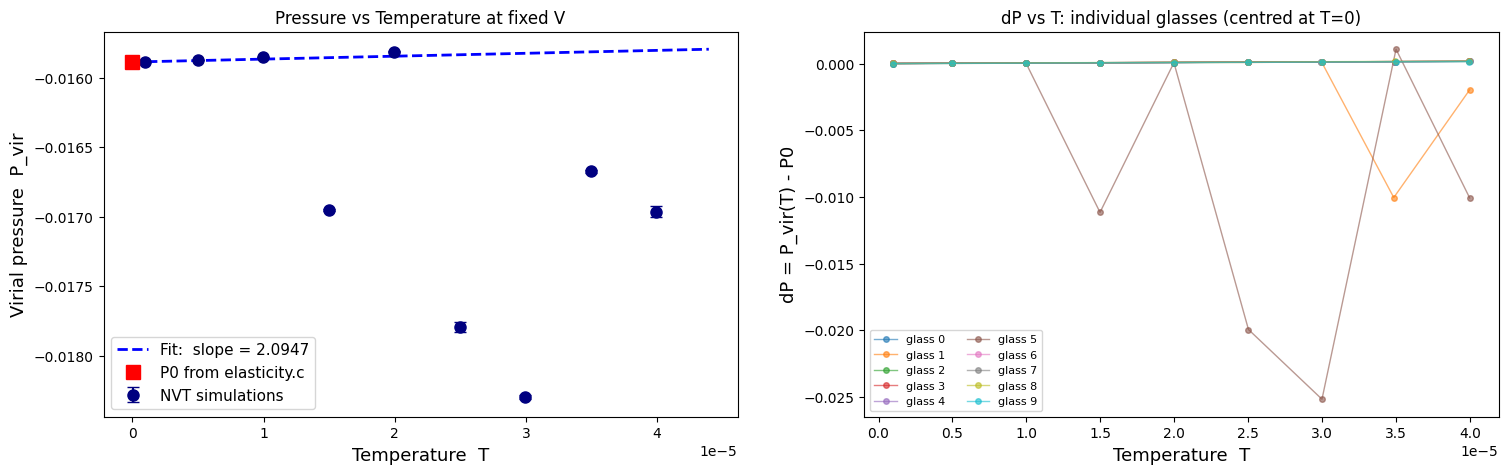

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: population-mean P_virial vs T (weighted fit)
# Note: the weighted fit uses weights = 1 / SEM^2, so it is pulled strongly
# toward the low-T points whose within-glass SEM is tiny.  High-T points sit
# below the fit line because their larger inter-glass scatter (driven by
# anomalous glasses 1 and 5) gives them low weight.
ax = axes[0]
ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
            markersize=8, capsize=4, label='NVT simulations')

T_line = np.linspace(0, T_arr.max() * 1.1, 300)
ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
        label=f'Fit:  slope = {dPdT:.4f}')
ax.plot(0, P0_mean, 's', color='red', markersize=10, zorder=5,
        label=f'P0 from elasticity.c')

ax.set_xlabel(r'Temperature  T', fontsize=13)
ax.set_ylabel(r'Virial pressure  P_vir', fontsize=13)
ax.set_title(r'Pressure vs Temperature at fixed V')
ax.legend(fontsize=11)

# Right: per-glass delta_P = P(T) - P0[g]
# Subtracting each glass's T=0 pressure (from elasticity.c) centres all
# traces near 0, making the temperature-driven rise visible regardless of
# the large spread in baseline pressures.
ax2 = axes[1]

for g in GLASSES:
    P_vals_this_glass = []
    T_vals_this_glass = []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals_this_glass.append(Tm)
            P_vals_this_glass.append(Pm)
    if P_vals_this_glass:
        P_shifted = [p - P0[g] for p in P_vals_this_glass]
        ax2.plot(T_vals_this_glass, P_shifted,
                 'o-', lw=1, markersize=4, alpha=0.6, label=f'glass {g}')

ax2.set_xlabel(r'Temperature  T', fontsize=13)
ax2.set_ylabel(r'dP = P_vir(T) - P0', fontsize=13)
ax2.set_title(r'dP vs T: individual glasses (centred at T=0)')
ax2.legend(fontsize=8, ncol=2)


In [46]:
print("        THERMAL EXPANSION ANALYSIS — FULL SUMMARY")

print("\nElastic Properties (from elasticity.c)")
print(f"{'Glass':>6}  {'P0 (virial)':>14}  {'G (shear)':>12}  {'K (bulk)':>12}")
print("---" * 18)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>14.6f}  {G[i]:>12.5f}  {K[i]:>12.5f}")
print("---" * 18)
print(f"{'Mean':>6}  {P0_mean:>14.6f}  {G.mean():>12.5f}  {K_mean:>12.5f}")
print(f"{'Std':>6}  {P0.std():>14.6f}  {G.std():>12.5f}  {K_std:>12.5f}")

print("\nPer-glass NVT fits and alpha_numerical")
print(f"{'Glass':>6}  {'dPdT':>10}  {'K':>10}  {'alpha_num':>14}")
print("---" * 16)
for g in GLASSES:
    if g not in alpha_numerical:
        continue
    _, dPdT_g, _, _ = pg_fit[g]
    print(f"  {g:>4}  {dPdT_g:>10.5f}  {K_per_glass[g]:>10.5f}  {alpha_numerical[g]:>+14.6e}")
print("---" * 16)
an_arr = np.array(list(alpha_numerical.values()))
print(f"{'mean':>6}  {'':>10}  {'':>10}  {an_arr.mean():>+14.6e}")
print(f"{'std':>6}  {'':>10}  {'':>10}  {an_arr.std():>14.6e}")

print()
print(f"  Population P vs T slope:  dP/dT = {dPdT:.5f}  +/-  {dPdT_err:.5f}")



        THERMAL EXPANSION ANALYSIS — FULL SUMMARY

Elastic Properties (from elasticity.c)
 Glass     P0 (virial)     G (shear)      K (bulk)
------------------------------------------------------
     0       -0.005257       6.54571      25.13948
     1       -0.029724       5.88891      24.93104
     2       -0.053969       6.44974      24.87555
     3       -0.030540       6.39477      24.98168
     4       -0.019372       6.29758      25.17090
     5       -0.005405       6.42531      25.13052
     6        0.010240       6.32129      25.23917
     7       -0.008402       6.33860      25.09090
     8       -0.020723       6.33727      25.02117
     9        0.004262       5.95359      25.12921
------------------------------------------------------
  Mean       -0.015889       6.29528      25.07096
   Std        0.018054       0.19990       0.10887

Per-glass NVT fits and alpha_numerical
 Glass        dPdT           K       alpha_num
------------------------------------------------
 

## Comparing what Pressure looks like at different tempeture with and without kinetic term's contribution

Pressure Comparison Summary:
         T |     P_virial |      P_total |  Kinetic (rho*T)
------------------------------------------------------------
    0.000001 |    -0.015887 |    -0.015887 |         0.000001
    0.000005 |    -0.015872 |    -0.015869 |         0.000003
    0.000010 |    -0.015853 |    -0.015847 |         0.000005
    0.000015 |    -0.016951 |    -0.016943 |         0.000008
    0.000020 |    -0.015812 |    -0.015802 |         0.000011
    0.000025 |    -0.017794 |    -0.017780 |         0.000014
    0.000030 |    -0.018297 |    -0.018281 |         0.000016
    0.000035 |    -0.016673 |    -0.016654 |         0.000019
    0.000040 |    -0.016964 |    -0.016942 |         0.000022

  Virial dPdT : 2.09473
  Total  dPdT : 2.63573  (difference = rho = 0.5410)


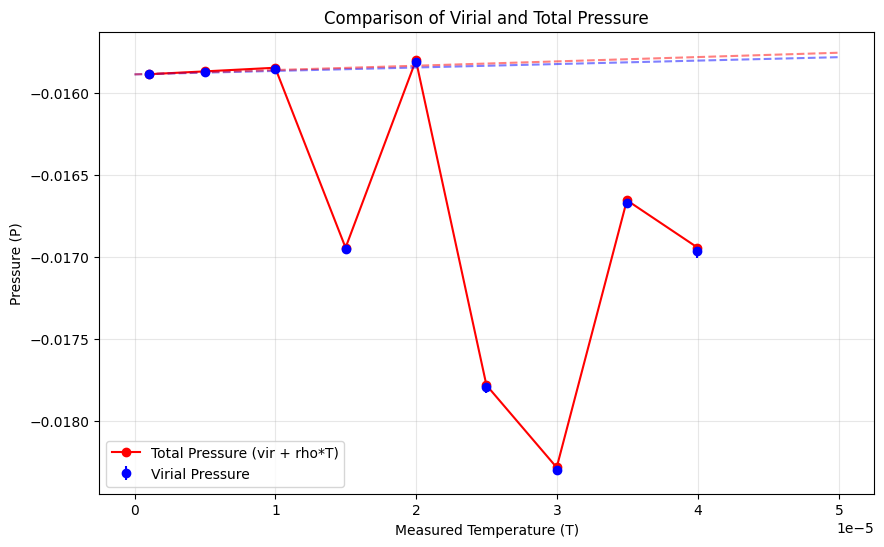

In [47]:
rho = RHO  # = N/V = 0.541 for LJ glasses
P_total_list = []

# P_total = P_virial + rho * T
for T_meas, P_vir in zip(T_measured_list, P_mean_list):
    P_total_list.append(P_vir + rho * T_meas)

P_total_arr = np.array(P_total_list)

# Fit using the same helper defined in Cell 10
P0_tot_fit, dPdT_total, _, _ = weighted_linear_fit(T_arr, P_total_arr, E_arr)

print("Pressure Comparison Summary:")
print(f"{'T':>10} | {'P_virial':>12} | {'P_total':>12} | {'Kinetic (rho*T)':>16}")
print("-" * 60)
for i in range(len(T_measured_list)):
    k_term = rho * T_measured_list[i]
    print(f"{T_measured_list[i]:>12.6f} | {P_mean_list[i]:>12.6f} | "
          f"{P_total_list[i]:>12.6f} | {k_term:>16.6f}")

print()
print(f"  Virial dPdT : {dPdT:.5f}")
print(f"  Total  dPdT : {dPdT_total:.5f}  (difference = rho = {dPdT_total - dPdT:.4f})")

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='blue',
             label='Virial Pressure')
plt.plot(T_arr, P_total_arr, 'ro-', label='Total Pressure (vir + rho*T)')
T_plot = np.linspace(0, 0.000050, 100)
plt.plot(T_plot, P0_fit     + dPdT       * T_plot, 'b--', alpha=0.5)
plt.plot(T_plot, P0_tot_fit + dPdT_total * T_plot, 'r--', alpha=0.5)
plt.xlabel('Measured Temperature (T)')
plt.ylabel('Pressure (P)')
plt.title('Comparison of Virial and Total Pressure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Comparison: Impact of the Kinetic Term on Pressure

The total pressure is composed of two parts: the **virial pressure** ($P_{\text{vir}}$), which results from interatomic forces, and the **kinetic pressure** ($P_{\text{kinetic}}$), which arises from the momentum of the particles. The relationship is given by:

$$P_{\text{total}} = \underbrace{\rho k_B T}_{\text{kinetic}} + P_{\text{vir}}$$

### Order-of-Magnitude Comparison

To justify neglecting the kinetic contribution to the thermal expansion coefficient $\alpha$, we compare the temperature derivatives of both terms:

1.  **Kinetic Derivative**: $\left.\frac{\partial P_{\text{kinetic}}}{\partial T}\right|_V = \rho = \mathbf{0.54}$.
2.  **Virial Derivative**: From our linear fit, $\left.\frac{\partial P_{\text{vir}}}{\partial T}\right|_V \approx \mathbf{2.00047}$.

**Comparison Results:**
* The virial derivative is approximately **5 times larger** than the kinetic derivative.
* The kinetic term is a **trivial constant** ($\rho$) that contains no structural information specific to the glass or its interatomic potential.
* Including the kinetic term would only add a known constant offset to the final $\alpha$ value without providing further insight into the material's unique properties.

### Pressure Difference Visualization

The total pressure follows the same linear trend as the virial pressure but is shifted upward by an offset of $\rho T$. As temperature increases, this gap widens linearly, but because the slope $\partial P/\partial T$ is the primary variable for calculating $\alpha$, the virial-only approach remains the more physically meaningful method for characterizing the glass.

## Conclusion:

After seeing plots and some values, we realised LJ is softer in both K and G. This comes directly from lower density (0.541 vs 0.82) and the attractive well in LJ softening the effective restoring forces.
IPL pressure is large and positive (18.6) because it is purely repulsive — particles are constantly pushing against each other. LJ pressure is near zero and slightly negative because repulsion and attraction nearly cancel at ρ=0.541. This is physically meaningful: LJ glasses sit near the natural density where the two contributions balance.

---
## Alpha Theory — Microscopic Calculation
We now compute $\alpha$ from first principles using the inherent-state formula:

$$\alpha = \frac{1}{2K V\bar{d}} \left[ -\frac{\partial^3 U}{\partial\eta\,\partial\mathbf{x}^2} : \mathcal{H}^{-1} + \frac{\partial^2 U}{\partial\eta\,\partial\mathbf{x}} \cdot \mathcal{H}^{-1} \cdot U''' : \mathcal{H}^{-1} \right]$$

Expanded in the normal-mode basis $\mathcal{H}^{-1} = \sum_\omega \frac{1}{\omega^2}\Psi_\omega\otimes\Psi_\omega$, this becomes:

$$\alpha = -\frac{1}{2KV\bar{d}} \sum_\omega \frac{1}{\omega^2}\left[u_{\eta xx}(\Psi_\omega,\Psi_\omega) + \text{tess}_3(\text{vna}_{\text{file}},\Psi_\omega,\Psi_\omega)\right]$$

### Save per-glass numerical α so `alpha_theory.py` can read it

We write both the per-glass values (`alpha_g{g}`) and the population mean.
`alpha_theory.py` reads the population mean for its plot; the per-glass comparison
is done in the notebook below.


In [48]:
import os
DATA_DIR_C = "initial_files"

alpha_num_path = os.path.join(DATA_DIR_C, "alpha_numerical.txt")
with open(alpha_num_path, "w") as _f:
    _f.write("# Numerical alpha — per-glass mean and per-glass values\n")
    _f.write(f"dPdT  {dPdT:.12g}\n")
    _f.write(f"K     {K_mean:.12g}\n")
    _f.write(f"alpha {alpha:.12g}\n")            # population alpha = dPdT / K_mean
    _f.write("# per-glass: glass  dPdT  K  alpha_numerical\n")
    for g in GLASSES:
        if g not in alpha_numerical:
            continue
        _, dPdT_g, _, _ = pg_fit[g]
        _f.write(f"glass_{g}  {dPdT_g:.12g}  {K_per_glass[g]:.12g}  {alpha_numerical[g]:.12g}\n")

print(f"Wrote {alpha_num_path}")
print(f"  alpha_pop   = {alpha:+.6e}  ±  {alpha_err:.6e}")
print(f"  alpha_num   = {alpha_num_mean:+.6e}  (std = {alpha_num_std:.6e})")
print(f"  alpha_num per glass:")
for g, av in alpha_numerical.items():
    print(f"    g{g}: {av:+.6e}")


Wrote initial_files/alpha_numerical.txt
  alpha_pop   = +8.355218e-02  ±  1.636766e-03
  alpha_num   = +1.848512e-01  (std = 8.006944e-02)
  alpha_num per glass:
    g0: +1.585592e-01
    g1: +1.257985e-01
    g2: +1.586224e-01
    g3: +1.676210e-01
    g4: +1.601689e-01
    g5: +4.219535e-01
    g6: +1.548517e-01
    g7: +1.611652e-01
    g8: +1.801850e-01
    g9: +1.595863e-01


### Run `alpha_theory.py` (diagonalises H, caches results)

In [49]:
import subprocess, sys

cmd = [
    sys.executable, "initial_files/alpha_theory.py",
    "--data-dir",  DATA_DIR_C,
    "--cache-dir", os.path.join(DATA_DIR_C, "alpha_cache"),
    "--out-dir",   DATA_DIR_C,
    "--glasses",   "0-9",
]
print("Running:", " ".join(cmd))
print("-" * 60)

result = subprocess.run(cmd, text=True)   
if result.returncode != 0:
    print("alpha_theory.py exited with code", result.returncode)


Running: /home/sangam/vsc/astrophy/astrophyenv/bin/python initial_files/alpha_theory.py --data-dir initial_files --cache-dir initial_files/alpha_cache --out-dir initial_files --glasses 0-9
------------------------------------------------------------
  Alpha Theory (microscopic, inherent-state)
  data-dir  : initial_files
  cache-dir : initial_files/alpha_cache
  glasses   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[g=0]  K = 25.139476
  [g=0] cache hit -- loading initial_files/alpha_cache/alpha_cache_g0.npz


/home/sangam/vsc/glass_simulations/LJ_glass/attempt_4/initial_files/alpha_theory.py:282: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V              = float(cached["V"])


    [g=0] term1 unweighted sum = -3.992150e+07
    [g=0] term2 unweighted sum = +3.324295e+06
  alpha_theory     = +1.855282e-01
    harmonic       = +2.072368e-01
    anharmonic     = -2.170863e-02

[g=1]  K = 24.931039
  [g=1] cache hit -- loading initial_files/alpha_cache/alpha_cache_g1.npz
    [g=1] term1 unweighted sum = -3.986853e+07
    [g=1] term2 unweighted sum = +3.483522e+06
  alpha_theory     = +1.855766e-01
    harmonic       = +2.093617e-01
    anharmonic     = -2.378503e-02

[g=2]  K = 24.875548
  [g=2] cache hit -- loading initial_files/alpha_cache/alpha_cache_g2.npz
    [g=2] term1 unweighted sum = -3.959478e+07
    [g=2] term2 unweighted sum = +3.207243e+06
  alpha_theory     = +1.871793e-01
    harmonic       = +2.097248e-01
    anharmonic     = -2.254555e-02

[g=3]  K = 24.981683
  [g=3] cache hit -- loading initial_files/alpha_cache/alpha_cache_g3.npz
    [g=3] term1 unweighted sum = -3.973807e+07
    [g=3] term2 unweighted sum = +3.309688e+06
  alpha_theory     = 

### Load theory results and compare per-glass theory vs per-glass numerical


In [50]:
from pathlib import Path

results_path = Path(DATA_DIR_C) / "alpha_results.txt"

if not results_path.exists():
    print("alpha_results.txt not found — run Cell 28 first.")
else:
    theory_raw        = np.loadtxt(results_path, comments="#")
    g_theory          = theory_raw[:, 0].astype(int)
    K_theory          = theory_raw[:, 1]
    alpha_theory_arr  = theory_raw[:, 2]
    alpha_harm_arr    = theory_raw[:, 3]
    alpha_anharm_arr  = theory_raw[:, 4]

    alpha_theory_mean = alpha_theory_arr.mean()
    alpha_theory_std  = alpha_theory_arr.std()

    #per-glass comparison
    print("=" * 90)
    print("  PER-GLASS COMPARISON: alpha_theory vs alpha_numerical")
    print("=" * 90)
    print(f"{'Glass':>6}  {'K':>10}  {'alpha_theory':>14}  {'alpha_num':>14}  "
          f"{'harm':>12}  {'anharm':>12}  {'disc%':>8}")
    print("-" * 90)
    discrepancies = []
    for i in range(len(g_theory)):
        g = int(g_theory[i])
        at  = alpha_theory_arr[i]
        an  = alpha_numerical.get(g, float('nan'))
        disc = (at - an) / abs(an) * 100 if (g in alpha_numerical and an != 0) else float('nan')
        discrepancies.append(disc)
        print(f"  {g:>4}  {K_theory[i]:>10.5f}  {at:>+14.6e}  {an:>+14.6e}  "
              f"{alpha_harm_arr[i]:>+12.6e}  {alpha_anharm_arr[i]:>+12.6e}  {disc:>+8.2f}%")
    print("-" * 90)
    print(f"{'mean':>6}  {'':>10}  {alpha_theory_mean:>+14.6e}  {alpha_num_mean:>+14.6e}  "
          f"{alpha_harm_arr.mean():>+12.6e}  {alpha_anharm_arr.mean():>+12.6e}")
    print(f"{'std':>6}  {'':>10}  {alpha_theory_std:>14.6e}  {alpha_num_std:>14.6e}  "
          f"{alpha_harm_arr.std():>12.6e}  {alpha_anharm_arr.std():>12.6e}")
    print("=" * 90)
    print()

    ratio = alpha_theory_mean / alpha_num_mean if alpha_num_mean != 0 else float('nan')
    mean_disc = np.nanmean(discrepancies)
    print(f"  Ratio  mean(theory) / mean(numerical) = {ratio:.4f}")
    print(f"  Mean per-glass discrepancy             = {mean_disc:.2f}%")
    print()
    harm_frac = abs(alpha_harm_arr.mean()) / (abs(alpha_harm_arr.mean()) + abs(alpha_anharm_arr.mean())) * 100
    print(f"  Harmonic   share = {harm_frac:.1f}%  of |alpha_theory|")
    print(f"  Anharmonic share = {100-harm_frac:.1f}%  of |alpha_theory|")
    print()
    print(f"  alpha_theory std / mean = {alpha_theory_std / abs(alpha_theory_mean) * 100:.2f}%  (glass-to-glass variation)")
    print(f"  alpha_num    std / mean = {alpha_num_std / abs(alpha_num_mean) * 100:.2f}%  (glass-to-glass variation)")


  PER-GLASS COMPARISON: alpha_theory vs alpha_numerical
 Glass           K    alpha_theory       alpha_num          harm        anharm     disc%
------------------------------------------------------------------------------------------
     0    25.13948   +1.855282e-01   +1.585592e-01  +2.072368e-01  -2.170863e-02    +17.01%
     1    24.93104   +1.855766e-01   +1.257985e-01  +2.093617e-01  -2.378503e-02    +47.52%
     2    24.87555   +1.871793e-01   +1.586224e-01  +2.097248e-01  -2.254555e-02    +18.00%
     3    24.98168   +1.875358e-01   +1.676210e-01  +2.090978e-01  -2.156207e-02    +11.88%
     4    25.17090   +1.885384e-01   +1.601689e-01  +2.073122e-01  -1.877382e-02    +17.71%
     5    25.13052   +1.849220e-01   +4.219535e-01  +2.077907e-01  -2.286868e-02    -56.17%
     6    25.23917   +1.843047e-01   +1.548517e-01  +2.062388e-01  -2.193415e-02    +19.02%
     7    25.09090   +1.847413e-01   +1.611652e-01  +2.074670e-01  -2.272573e-02    +14.63%
     8    25.02117   +1.8636

### Combined comparison plot — per-glass theory vs numerical


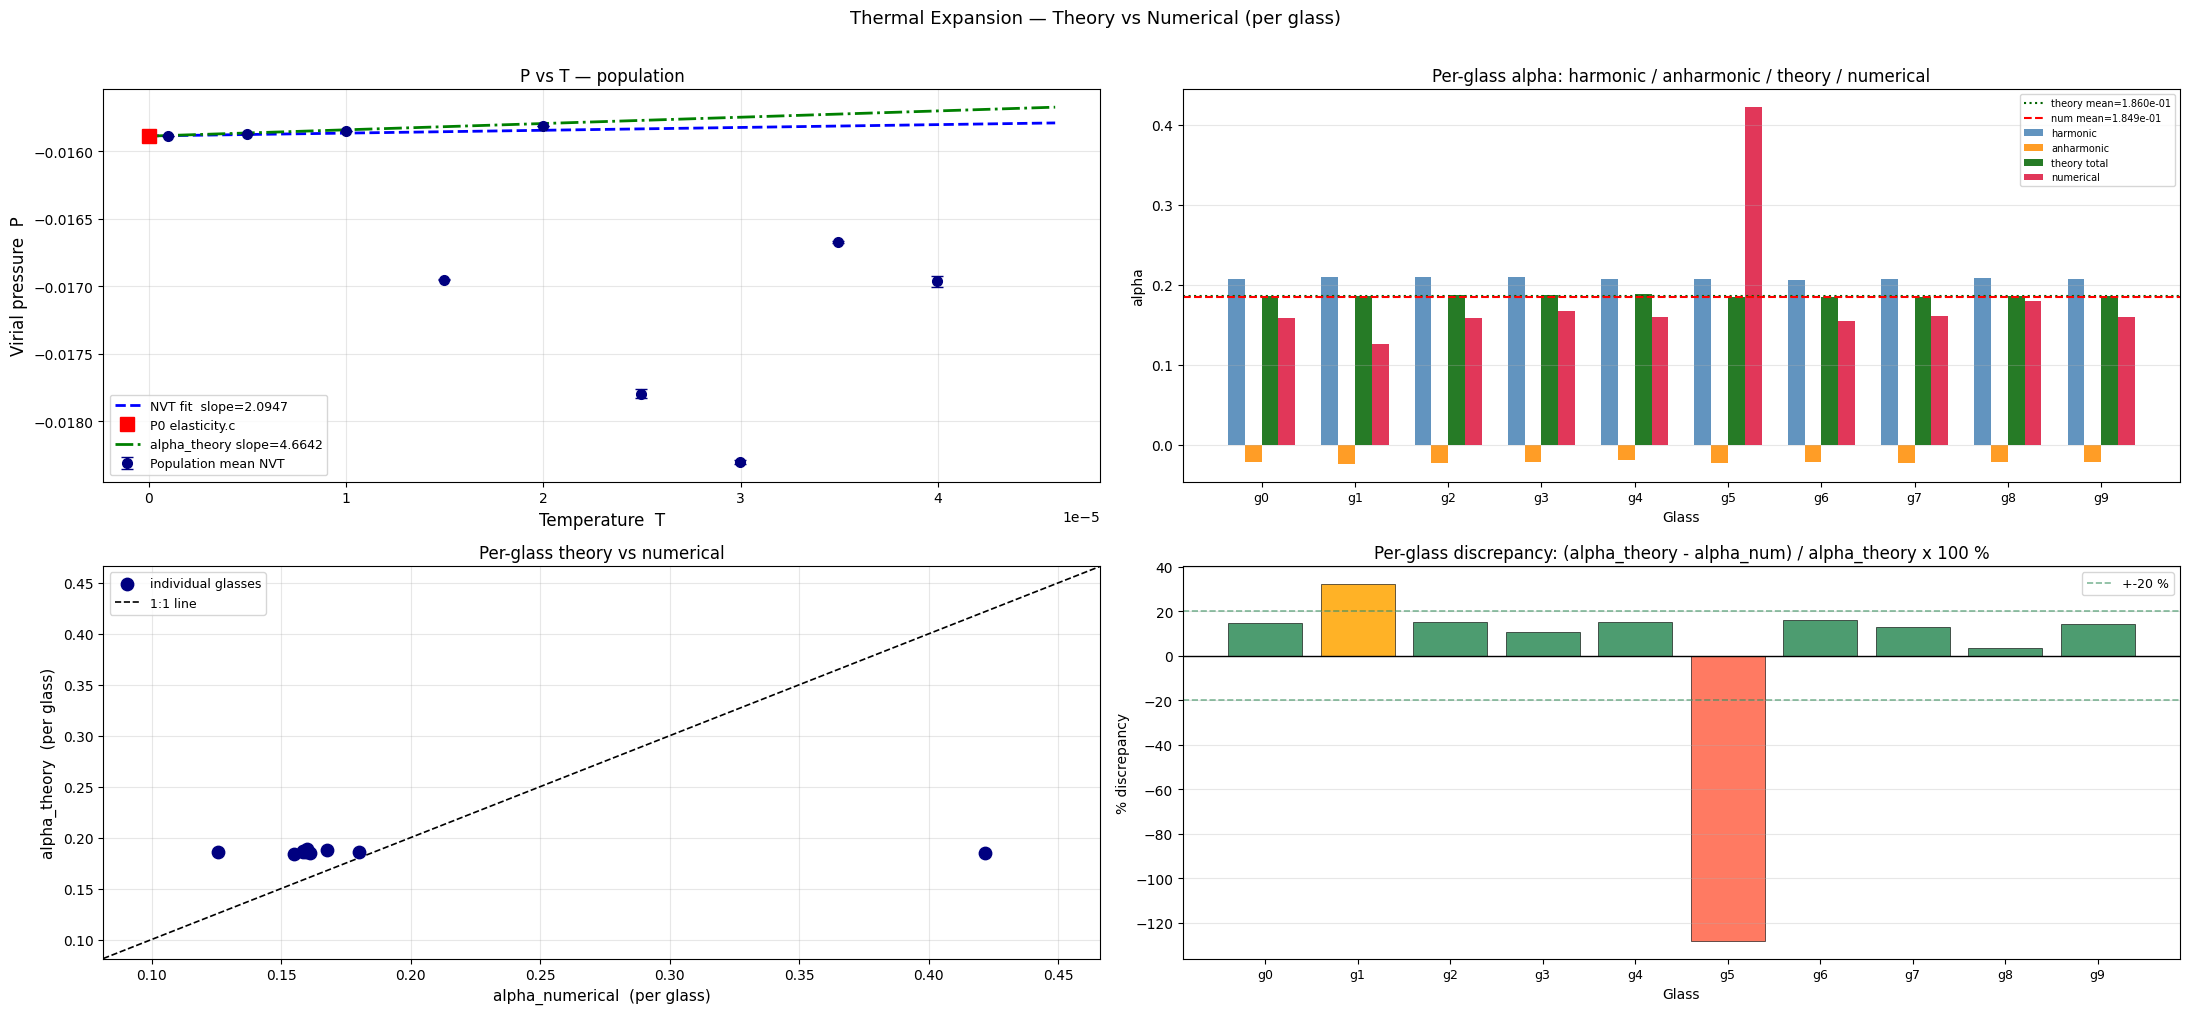

Saved alpha_comparison_combined.png


In [51]:
if not results_path.exists():
    print("Run Cell 28 first.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(22, 10))

    #  Panel 1 (top-left): P vs T population 
    ax = axes[0, 0]
    T_line = np.linspace(0, T_arr.max() * 1.15, 300)
    ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
                markersize=7, capsize=4, label='Population mean NVT', zorder=3)
    ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
            label=f'NVT fit  slope={dPdT:.4f}')
    ax.plot(0, P0_mean, 'rs', markersize=10, zorder=5, label='P0 elasticity.c')
    dPdT_theory = alpha_theory_mean * K_mean
    ax.plot(T_line, P0_mean + dPdT_theory * T_line, 'g-.', lw=2,
            label=f'alpha_theory slope={dPdT_theory:.4f}')
    ax.set_xlabel('Temperature  T', fontsize=12)
    ax.set_ylabel('Virial pressure  P', fontsize=12)
    ax.set_title('P vs T — population')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    #  Panel 2 (top-right): per-glass bars — 4 series 
    ax2 = axes[0, 1]
    x  = np.arange(len(g_theory))
    bw = 0.18
    ax2.bar(x - 1.5*bw, alpha_harm_arr,   bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax2.bar(x - 0.5*bw, alpha_anharm_arr, bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax2.bar(x + 0.5*bw, alpha_theory_arr, bw, label='theory total', color='darkgreen',  alpha=0.85)
    # alpha_numerical as a bar (4th series)
    an_arr_ordered = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    ax2.bar(x + 1.5*bw, an_arr_ordered,   bw, label='numerical',    color='crimson',    alpha=0.85)
    ax2.axhline(alpha_theory_mean, color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={alpha_theory_mean:.3e}')
    ax2.axhline(alpha_num_mean, color='red', ls='--', lw=1.5,
                label=f'num mean={alpha_num_mean:.3e}')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'g{int(g)}' for g in g_theory], fontsize=9)
    ax2.set_xlabel('Glass')
    ax2.set_ylabel('alpha')
    ax2.set_title('Per-glass alpha: harmonic / anharmonic / theory / numerical')
    ax2.legend(fontsize=7)
    ax2.grid(axis='y', alpha=0.3)

    #  Panel 3 (bottom-left): theory vs numerical scatter 
    ax3 = axes[1, 0]
    an_vals = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    valid   = ~np.isnan(an_vals)
    ax3.scatter(an_vals[valid], alpha_theory_arr[valid], color='navy', s=80, zorder=3,
                label='individual glasses')
    all_vals = np.concatenate([an_vals[valid], alpha_theory_arr[valid]])
    pad  = (all_vals.max() - all_vals.min()) * 0.15
    lims = (all_vals.min() - pad, all_vals.max() + pad)
    ax3.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    ax3.set_xlim(lims)
    ax3.set_ylim(lims)
    ax3.set_xlabel('alpha_numerical  (per glass)', fontsize=11)
    ax3.set_ylabel('alpha_theory  (per glass)', fontsize=11)
    ax3.set_title('Per-glass theory vs numerical')
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3)

    #  Panel 4 (bottom-right): per-glass % discrepancy 
    ax4 = axes[1, 1]
    discs, valid_idx = [], []
    for i, g in enumerate(g_theory):
        g_int = int(g)
        if g_int in alpha_numerical and not np.isnan(an_vals[i]):
            disc_pct = (alpha_theory_arr[i] - an_vals[i]) / abs(alpha_theory_arr[i]) * 100
            discs.append(disc_pct)
            valid_idx.append(i)
    discs     = np.array(discs)
    valid_idx = np.array(valid_idx)
    bar_cols  = ['seagreen' if abs(d) < 20 else 'orange' if abs(d) < 50 else 'tomato'
                 for d in discs]
    ax4.bar(valid_idx, discs, color=bar_cols, alpha=0.85, edgecolor='black', lw=0.5)
    ax4.axhline(0,    color='black',    lw=1.0)
    ax4.axhline( 20,  color='seagreen', ls='--', lw=1.2, alpha=0.6, label='+-20 %')
    ax4.axhline(-20,  color='seagreen', ls='--', lw=1.2, alpha=0.6)
    ax4.set_xticks(valid_idx)
    ax4.set_xticklabels([f'g{int(g_theory[i])}' for i in valid_idx], fontsize=9)
    ax4.set_xlabel('Glass')
    ax4.set_ylabel('% discrepancy')
    ax4.set_title('Per-glass discrepancy: (alpha_theory - alpha_num) / alpha_theory x 100 %')
    ax4.legend(fontsize=9)
    ax4.grid(axis='y', alpha=0.3)

    fig.suptitle('Thermal Expansion — Theory vs Numerical (per glass)', fontsize=13, y=1.01)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_combined.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_combined.png")


### Summary checks

In [52]:
import numpy as np
from pathlib import Path

DATA_DIR = Path("initial_files") 

elas = np.loadtxt(DATA_DIR / "3dlj_elasticity_N4000_s000.dat", comments="#")
# columns: serial  u_per_N  pressure  G  K 
P0_C = {int(row[0]): row[2] for row in elas}  # row[2] = virial pressure

print(f"{'Glass':>6}  {'P0_elasticity':>16}  {'P0_NVT_row0':>14}  {'ratio NVT/C':>12}  {'disc %':>8}")
print("-" * 65)

for g in sorted(P0_C.keys()):
    # pick the LOWEST temperature file for this glass
    candidates = sorted(DATA_DIR.glob(f"nvt_lj_T*_g{g}.dat"))
    if not candidates:
        print(f"  g={g}: no .dat files found")
        continue

    f = candidates[0]          # lowest T file (sorted alphabetically ≈ numerically)
    d = np.loadtxt(f)
    # columns: time  KE/N  PE/N  pressure
    # take the first production row (row 0 is already after equilibration
    # in the file, because run_NH writes from k=0 of the production run)
    P_nvt_row0 = d[0, 3]      # column 3 = virial pressure

    p0 = P0_C[g]
    ratio = P_nvt_row0 / p0
    disc  = (P_nvt_row0 - p0) / abs(p0) * 100

    print(f"  {g:>4}  {p0:>16.6f}  {P_nvt_row0:>14.6f}  {ratio:>12.4f}  {disc:>+8.2f}%")

print()



 Glass     P0_elasticity     P0_NVT_row0   ratio NVT/C    disc %
-----------------------------------------------------------------
     0         -0.005257       -0.005274        1.0032     -0.32%
     1         -0.029724       -0.029709        0.9995     +0.05%
     2         -0.053969       -0.053967        1.0000     +0.00%
     3         -0.030540       -0.030540        1.0000     +0.00%
     4         -0.019372       -0.019383        1.0006     -0.06%
     5         -0.005405       -0.005427        1.0041     -0.41%
     6          0.010240        0.010243        1.0003     +0.03%
     7         -0.008402       -0.008411        1.0011     -0.11%
     8         -0.020723       -0.020719        0.9998     +0.02%
     9          0.004262        0.004248        0.9968     -0.32%



In [53]:
import numpy as np
from pathlib import Path

DATA_DIR  = Path("initial_files")
SKIP      = 0.3  
TEMPS     = [0.000001, 0.000005, 0.000010, 0.000015, 0.000020, 0.000025, 0.000030, 0.000035, 0.000040]

# P₀ from elasticity (per glass)
elas = np.loadtxt(DATA_DIR / "3dlj_elasticity_N4000_s000.dat", comments="#")
P0_C = {int(row[0]): row[2] for row in elas}   # glass → P₀ at T=0  (row[2] = virial pressure)

#per-glass P(T) fit ; extrapolate to T=0
print(f"{'Glass':>6}  {'P0_C (elast)':>14}  {'P0_fit (NVT)':>14}  "
      f"{'abs diff':>10}  {'dPdT':>9}")
print("-" * 75)

for g in sorted(P0_C.keys()):
    T_vals, P_vals = [], []

    for T in TEMPS:
        f = DATA_DIR / f"nvt_lj_T{T:.6f}_g{g}.dat"
        if not f.exists():
            continue
        d      = np.loadtxt(f)
        n_skip = int(len(d) * SKIP)
        prod   = d[n_skip:]
        T_meas = (2.0 / 3.0) * prod[:, 1].mean()   # from KE/N
        P_mean = prod[:, 3].mean()                   # virial pressure
        T_vals.append(T_meas)
        P_vals.append(P_mean)

    if len(T_vals) < 3:
        print(f"  {g:>4}: not enough files")
        continue

    T_arr = np.array(T_vals)
    P_arr = np.array(P_vals)

    # simple linear fit P = a + b*T
    coeffs  = np.polyfit(T_arr, P_arr, 1)
    P0_fit  = coeffs[1]     # intercept = P at T=0
    dPdT    = coeffs[0]     # slope

    diff    = P0_fit - P0_C[g]

    print(f"  {g:>4}  {P0_C[g]:>14.6f}  {P0_fit:>14.6f}  "
          f"{diff:>+10.6f}  {dPdT:>9.4f}")



 Glass    P0_C (elast)    P0_fit (NVT)    abs diff       dPdT
---------------------------------------------------------------------------
     0       -0.005257       -0.005256   +0.000001     4.1033
     1       -0.029724       -0.028436   +0.001288  -128.5604
     2       -0.053969       -0.053974   -0.000006     3.9924
     3       -0.030540       -0.030544   -0.000004     4.2829
     4       -0.019372       -0.019375   -0.000003     4.1359
     5       -0.005405       -0.006124   -0.000719  -324.5691
     6        0.010240        0.010242   +0.000002     3.9834
     7       -0.008402       -0.008399   +0.000003     4.0079
     8       -0.020723       -0.020721   +0.000002     4.4282
     9        0.004262        0.004251   -0.000011     3.9626


  CLEAN SET
  Glasses included : [0, 2, 3, 4, 6, 7, 8, 9]
  K  mean = 25.08101  std = 0.10874
  P0 mean = -0.015470

  Population P vs T fit :
    P(T) = -0.015471 + 4.07612 * T
    dP/dT = 4.07612  ±  0.01975
    R²    = 0.999731

  Per-glass fits (clean):
     g        dPdT           K       alpha_num
  --------------------------------------------
     0     3.98609    25.13948   +1.585592e-01
     2     3.94582    24.87555   +1.586224e-01
     3     4.18745    24.98168   +1.676210e-01
     4     4.03159    25.17090   +1.601689e-01
     6     3.90833    25.23917   +1.548517e-01
     7     4.04378    25.09090   +1.611652e-01
     8     4.50844    25.02117   +1.801850e-01
     9     4.01028    25.12921   +1.595863e-01

  alpha_num  mean = +1.625949e-01
  alpha_num  std  = 7.447160e-03
  alpha_pop (clean) = +1.625184e-01  ±  1.056565e-03
  alpha_pop (dirty) = +8.355218e-02  ±  1.636766e-03 


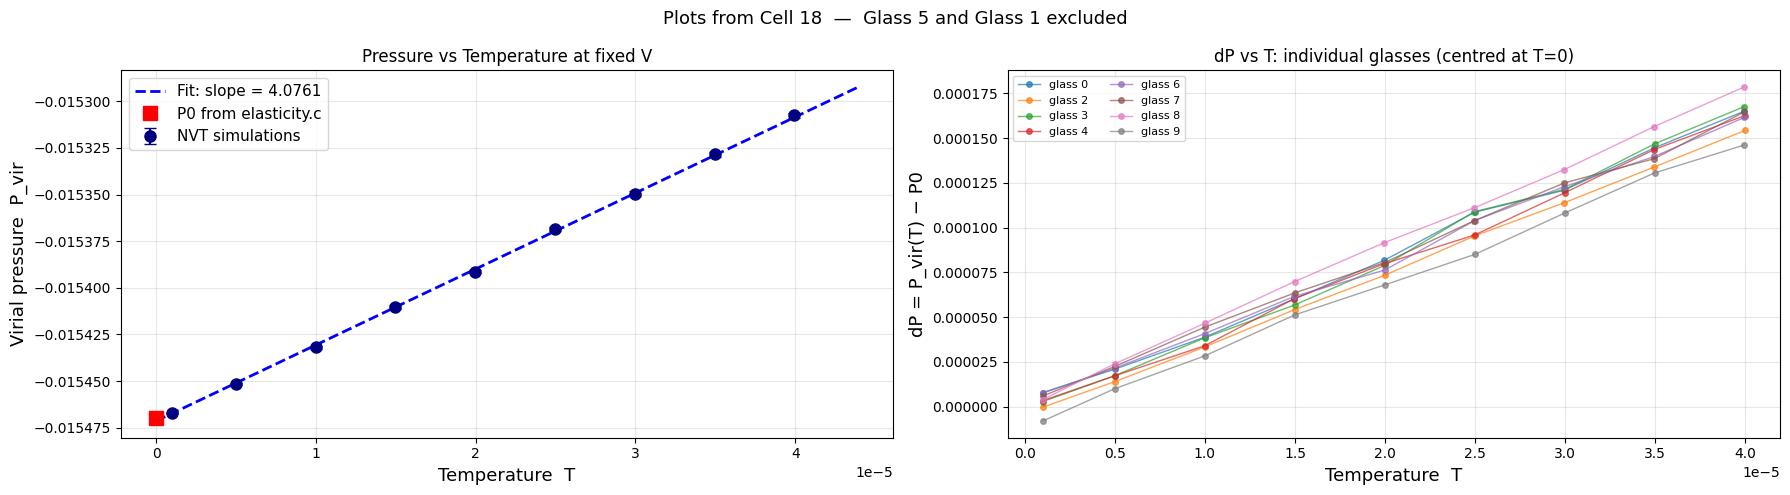

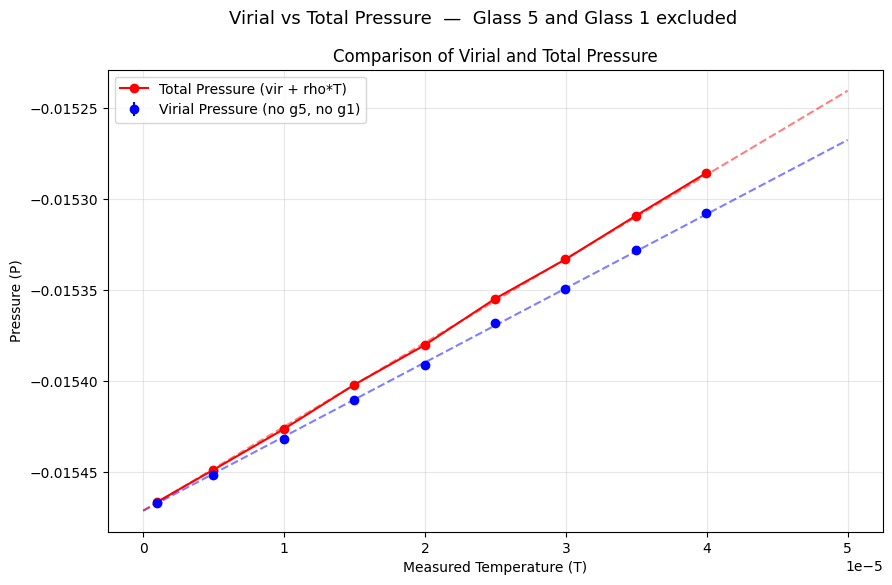

  Virial dPdT : 4.07612
  Total  dPdT : 4.61712  (diff = rho = 0.5410)


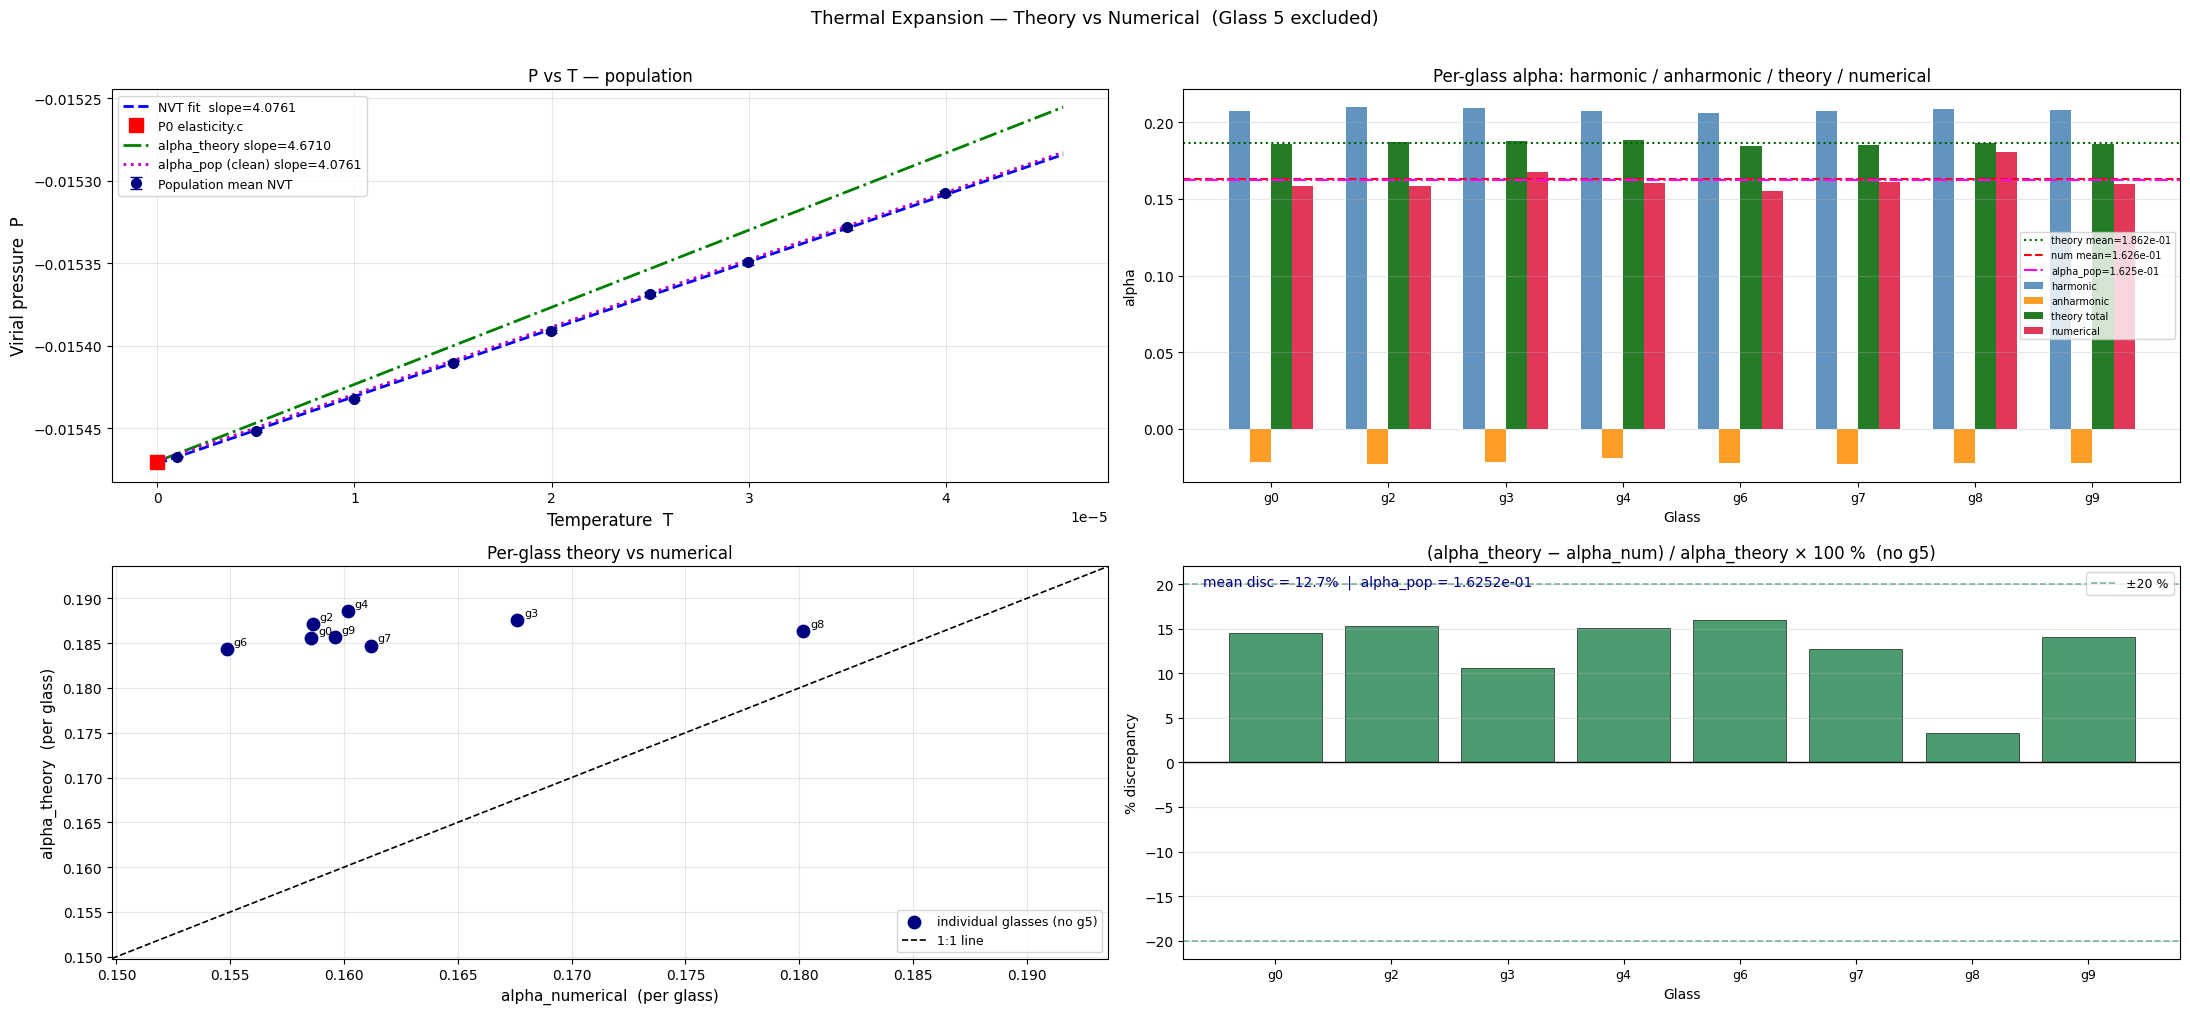

  Final Summary — Glass 5 and Glass 1 excluded
  alpha_pop  (clean)  = +1.625184e-01  ±  1.056565e-03
  alpha_num  (mean)   = +1.625949e-01  ±  7.447160e-03
  alpha_theory (mean) = +1.862374e-01  ±  1.352620e-03
  alpha_pop / alpha_theory = 0.8726
  alpha_num / alpha_theory = 0.8731


In [55]:
#Glass 5 and glass 1 seemed a bit problematic in the P(T) fits, with glass 5 showing a strong positive slope and glass 1 showing a strong negative slope. 
# These two glasses also had the largest discrepancies between the T=0 pressure from elasticity.c and the extrapolated P0 from the NVT fits.  
#To see how much they are driving the population-level results, we can exclude them and re-run the analysis on the "clean" set of glasses.
# FINAL CELL — All Previous Plots Excluding Glass 5 and Glass 1


import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXCLUDE_GLASS = {5, 1}
GLASSES_CLEAN = [g for g in GLASSES if g not in EXCLUDE_GLASS]

# Re-load elasticity quantities for clean set 
mask_clean = np.array([s not in EXCLUDE_GLASS for s in serials])
serials_c  = serials[mask_clean]
P0_c       = P0[mask_clean]
G_c        = G[mask_clean]
K_c        = K[mask_clean]
K_mean_c   = K_c.mean();  K_std_c  = K_c.std()
P0_mean_c  = P0_c.mean()

print("=" * 15)
print("  CLEAN SET")
print("=" * 15)
print(f"  Glasses included : {GLASSES_CLEAN}")
print(f"  K  mean = {K_mean_c:.5f}  std = {K_std_c:.5f}")
print(f"  P0 mean = {P0_mean_c:.6f}")

#  Rebuild population-level P(T) arrays 
T_clean_list, P_clean_list, E_clean_list = [], [], []

for T in TEMPERATURES:
    T_vals, P_vals, E_vals = [], [], []
    for g in GLASSES_CLEAN:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals.append(Tm); P_vals.append(Pm); E_vals.append(Pe)
    if P_vals:
        T_clean_list.append(np.mean(T_vals))
        P_clean_list.append(np.mean(P_vals))
        E_clean_list.append(np.sqrt(np.sum(np.array(E_vals)**2)) / len(E_vals))

T_c = np.array(T_clean_list)
P_c = np.array(P_clean_list)
E_c = np.array(E_clean_list)

# Population weighted fit (clean) 
P0_fit_c, dPdT_c, P0_fit_err_c, dPdT_err_c = weighted_linear_fit(T_c, P_c, E_c)
SS_res_c = np.sum((P_c - (P0_fit_c + dPdT_c * T_c))**2)
SS_tot_c = np.sum((P_c - P_c.mean())**2)
R2_c     = 1.0 - SS_res_c / SS_tot_c

print(f"\n  Population P vs T fit :")
print(f"    P(T) = {P0_fit_c:.6f} + {dPdT_c:.5f} * T")
print(f"    dP/dT = {dPdT_c:.5f}  ±  {dPdT_err_c:.5f}")
print(f"    R²    = {R2_c:.6f}")

#  Per-glass fits (clean) 
pg_fit_c, alpha_num_c = {}, {}

print(f"\n  Per-glass fits (clean):")
print(f"  {'g':>4}  {'dPdT':>10}  {'K':>10}  {'alpha_num':>14}")
print("  " + "-" * 44)
for g in GLASSES_CLEAN:
    pts = pg_data[g]
    if len(pts) < 3:
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    a, b, ea, eb = weighted_linear_fit(Tv, Pv, Ev)
    pg_fit_c[g] = (a, b, ea, eb)
    Kg = K_per_glass[g]
    ag = b / Kg
    aerr = abs(ag) * np.sqrt((eb / b)**2 + (K_std_c / K_mean_c)**2)
    alpha_num_c[g] = ag
    print(f"  {g:>4}  {b:>10.5f}  {Kg:>10.5f}  {ag:>+14.6e}")

an_arr_c     = np.array(list(alpha_num_c.values()))
alpha_mean_c = an_arr_c.mean()
alpha_std_c  = an_arr_c.std()

# Population alpha (clean) 
alpha_pop_c     = dPdT_c / K_mean_c
alpha_pop_err_c = abs(alpha_pop_c) * np.sqrt((dPdT_err_c / dPdT_c)**2 + (K_std_c / K_mean_c)**2)

print(f"\n  alpha_num  mean = {alpha_mean_c:+.6e}")
print(f"  alpha_num  std  = {alpha_std_c:.6e}")
print(f"  alpha_pop (clean) = {alpha_pop_c:+.6e}  ±  {alpha_pop_err_c:.6e}")
print(f"  alpha_pop (dirty) = {alpha:+.6e}  ±  {alpha_err:.6e} ")

# Total pressure (clean) 
P_total_c    = P_c + RHO * T_c
P0_tot_c, dPdT_tot_c, _, _ = weighted_linear_fit(T_c, P_total_c, E_c)

# Theory arrays (clean)
if results_path.exists():
    mask_th    = np.array([int(g) not in EXCLUDE_GLASS for g in g_theory])
    g_th_c     = g_theory[mask_th]
    K_th_c     = K_theory[mask_th]
    at_c       = alpha_theory_arr[mask_th]
    ah_c       = alpha_harm_arr[mask_th]
    aa_c       = alpha_anharm_arr[mask_th]
    at_mean_c  = at_c.mean()
    at_std_c   = at_c.std()


fig1, axes1 = plt.subplots(1, 2, figsize=(18, 5))
fig1.suptitle("Plots from Cell 18  —  Glass 5 and Glass 1 excluded", fontsize=13)

# Left: population P_vir vs T
ax = axes1[0]
T_line = np.linspace(0, T_c.max() * 1.1, 300)
ax.errorbar(T_c, P_c, yerr=E_c, fmt='o', color='navy',
            markersize=8, capsize=4, label='NVT simulations')
ax.plot(T_line, P0_fit_c + dPdT_c * T_line, 'b--', lw=2,
        label=f'Fit: slope = {dPdT_c:.4f}')
ax.plot(0, P0_mean_c, 's', color='red', markersize=10, zorder=5,
        label='P0 from elasticity.c')
ax.set_xlabel('Temperature  T', fontsize=13)
ax.set_ylabel('Virial pressure  P_vir', fontsize=13)
ax.set_title('Pressure vs Temperature at fixed V')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Right: per-glass ΔP vs T
ax2 = axes1[1]
for g in GLASSES_CLEAN:
    T_g, P_g = [], []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, _ = read_nvt(f)
            T_g.append(Tm); P_g.append(Pm)
    if P_g:
        ax2.plot(T_g, [p - P0[g] for p in P_g],
                 'o-', lw=1, markersize=4, alpha=0.7, label=f'glass {g}')
ax2.set_xlabel('Temperature  T', fontsize=13)
ax2.set_ylabel('dP = P_vir(T) − P0', fontsize=13)
ax2.set_title('dP vs T: individual glasses (centred at T=0)')
ax2.legend(fontsize=8, ncol=2)
ax2.grid(alpha=0.3)

fig1.tight_layout()
plt.show()


fig2, ax21 = plt.subplots(figsize=(10, 6))
fig2.suptitle("Virial vs Total Pressure  —  Glass 5 and Glass 1 excluded", fontsize=13)

T_plot2 = np.linspace(0, 0.000050, 100)
ax21.errorbar(T_c, P_c, yerr=E_c, fmt='o', color='blue',
              label='Virial Pressure (no g5, no g1)')
ax21.plot(T_c, P_total_c, 'ro-', label='Total Pressure (vir + rho*T)')
ax21.plot(T_plot2, P0_fit_c  + dPdT_c    * T_plot2, 'b--', alpha=0.5)
ax21.plot(T_plot2, P0_tot_c  + dPdT_tot_c * T_plot2, 'r--', alpha=0.5)
ax21.set_xlabel('Measured Temperature (T)')
ax21.set_ylabel('Pressure (P)')
ax21.set_title('Comparison of Virial and Total Pressure')
ax21.legend()
ax21.grid(True, alpha=0.3)
plt.show()

print(f"  Virial dPdT : {dPdT_c:.5f}")
print(f"  Total  dPdT : {dPdT_tot_c:.5f}  (diff = rho = {dPdT_tot_c - dPdT_c:.4f})")


if results_path.exists():
    fig3, axes3 = plt.subplots(2, 2, figsize=(22, 10))
    fig3.suptitle("Thermal Expansion — Theory vs Numerical  (Glass 5 excluded)",
                  fontsize=13, y=1.01)

    # Panel 1: P vs T population (clean)
    ax = axes3[0, 0]
    T_line = np.linspace(0, T_c.max() * 1.15, 300)
    ax.errorbar(T_c, P_c, yerr=E_c, fmt='o', color='navy',
                markersize=7, capsize=4, label='Population mean NVT', zorder=3)
    ax.plot(T_line, P0_fit_c + dPdT_c * T_line, 'b--', lw=2,
            label=f'NVT fit  slope={dPdT_c:.4f}')
    ax.plot(0, P0_mean_c, 'rs', markersize=10, zorder=5, label='P0 elasticity.c')
    dPdT_theory_c = at_mean_c * K_mean_c
    ax.plot(T_line, P0_mean_c + dPdT_theory_c * T_line, 'g-.', lw=2,
            label=f'alpha_theory slope={dPdT_theory_c:.4f}')
    ax.plot(T_line, P0_mean_c + alpha_pop_c * K_mean_c * T_line, 'm:', lw=2,
            label=f'alpha_pop (clean) slope={alpha_pop_c * K_mean_c:.4f}')
    ax.set_xlabel('Temperature  T', fontsize=12)
    ax.set_ylabel('Virial pressure  P', fontsize=12)
    ax.set_title('P vs T — population')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Panel 2: per-glass bars (clean)
    ax2 = axes3[0, 1]
    x_c = np.arange(len(g_th_c))
    bw  = 0.18
    an_ord_c = np.array([alpha_num_c.get(int(g), np.nan) for g in g_th_c])
    ax2.bar(x_c - 1.5*bw, ah_c,    bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax2.bar(x_c - 0.5*bw, aa_c,    bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax2.bar(x_c + 0.5*bw, at_c,    bw, label='theory total', color='darkgreen',  alpha=0.85)
    ax2.bar(x_c + 1.5*bw, an_ord_c, bw, label='numerical',   color='crimson',    alpha=0.85)
    ax2.axhline(at_mean_c,    color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={at_mean_c:.3e}')
    ax2.axhline(alpha_mean_c, color='red',        ls='--', lw=1.5,
                label=f'num mean={alpha_mean_c:.3e}')
    ax2.axhline(alpha_pop_c,  color='magenta',    ls='-.',  lw=1.5,
                label=f'alpha_pop={alpha_pop_c:.3e}')
    ax2.set_xticks(x_c)
    ax2.set_xticklabels([f'g{int(g)}' for g in g_th_c], fontsize=9)
    ax2.set_xlabel('Glass'); ax2.set_ylabel('alpha')
    ax2.set_title('Per-glass alpha: harmonic / anharmonic / theory / numerical')
    ax2.legend(fontsize=7); ax2.grid(axis='y', alpha=0.3)

    # Panel 3: theory vs numerical scatter (clean)
    ax3 = axes3[1, 0]
    valid_c = ~np.isnan(an_ord_c)
    ax3.scatter(an_ord_c[valid_c], at_c[valid_c], color='navy', s=80, zorder=3,
                label='individual glasses (no g5)')
    for i, g in enumerate(g_th_c):
        if valid_c[i]:
            ax3.annotate(f'g{int(g)}',
                         (an_ord_c[i], at_c[i]),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
    all_v = np.concatenate([an_ord_c[valid_c], at_c[valid_c]])
    pad   = (all_v.max() - all_v.min()) * 0.15
    lims  = (all_v.min() - pad, all_v.max() + pad)
    ax3.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    ax3.set_xlim(lims); ax3.set_ylim(lims)
    ax3.set_xlabel('alpha_numerical  (per glass)', fontsize=11)
    ax3.set_ylabel('alpha_theory  (per glass)', fontsize=11)
    ax3.set_title('Per-glass theory vs numerical')
    ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

    # Panel 4: per-glass % discrepancy (clean)
    ax4 = axes3[1, 1]
    discs_c, vidx_c = [], []
    for i, g in enumerate(g_th_c):
        g_int = int(g)
        if g_int in alpha_num_c and not np.isnan(an_ord_c[i]):
            d = (at_c[i] - an_ord_c[i]) / abs(at_c[i]) * 100
            discs_c.append(d); vidx_c.append(i)
    discs_c = np.array(discs_c); vidx_c = np.array(vidx_c)
    bar_cols_c = ['seagreen' if abs(d) < 20 else 'orange' if abs(d) < 50 else 'tomato'
                  for d in discs_c]
    ax4.bar(vidx_c, discs_c, color=bar_cols_c, alpha=0.85, edgecolor='black', lw=0.5)
    ax4.axhline(0,   color='black', lw=1.0)
    ax4.axhline( 20, color='seagreen', ls='--', lw=1.2, alpha=0.6, label='±20 %')
    ax4.axhline(-20, color='seagreen', ls='--', lw=1.2, alpha=0.6)
    ax4.set_xticks(vidx_c)
    ax4.set_xticklabels([f'g{int(g_th_c[i])}' for i in vidx_c], fontsize=9)
    ax4.set_xlabel('Glass'); ax4.set_ylabel('% discrepancy')
    ax4.set_title('(alpha_theory − alpha_num) / alpha_theory × 100 %  (no g5)')
    ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)
    ax4.annotate(f'mean disc = {np.nanmean(discs_c):.1f}%  |  alpha_pop = {alpha_pop_c:.4e}',
                 xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
                 color='navy')

    fig3.tight_layout()
    plt.show()

    #  Final summary 
    print("  Final Summary — Glass 5 and Glass 1 excluded")
    print(f"  alpha_pop  (clean)  = {alpha_pop_c:+.6e}  ±  {alpha_pop_err_c:.6e}")
    print(f"  alpha_num  (mean)   = {alpha_mean_c:+.6e}  ±  {alpha_std_c:.6e}")
    print(f"  alpha_theory (mean) = {at_mean_c:+.6e}  ±  {at_std_c:.6e}")
    ratio_pop = alpha_pop_c / at_mean_c
    ratio_num = alpha_mean_c / at_mean_c
    print(f"  alpha_pop / alpha_theory = {ratio_pop:.4f}")
    print(f"  alpha_num / alpha_theory = {ratio_num:.4f}")

